In [ ]:
import sys
import gmsh
import pyvista
import numpy as np
import adios4dolfinx
import matplotlib.pyplot as plt
import adios4dolfinx

from pathlib import Path
from mpi4py import MPI
from dolfinx import fem, io, plot
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element
from petsc4py import PETSc

from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, rhs, sym)


Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 21555 nodes
Info    : 43118 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


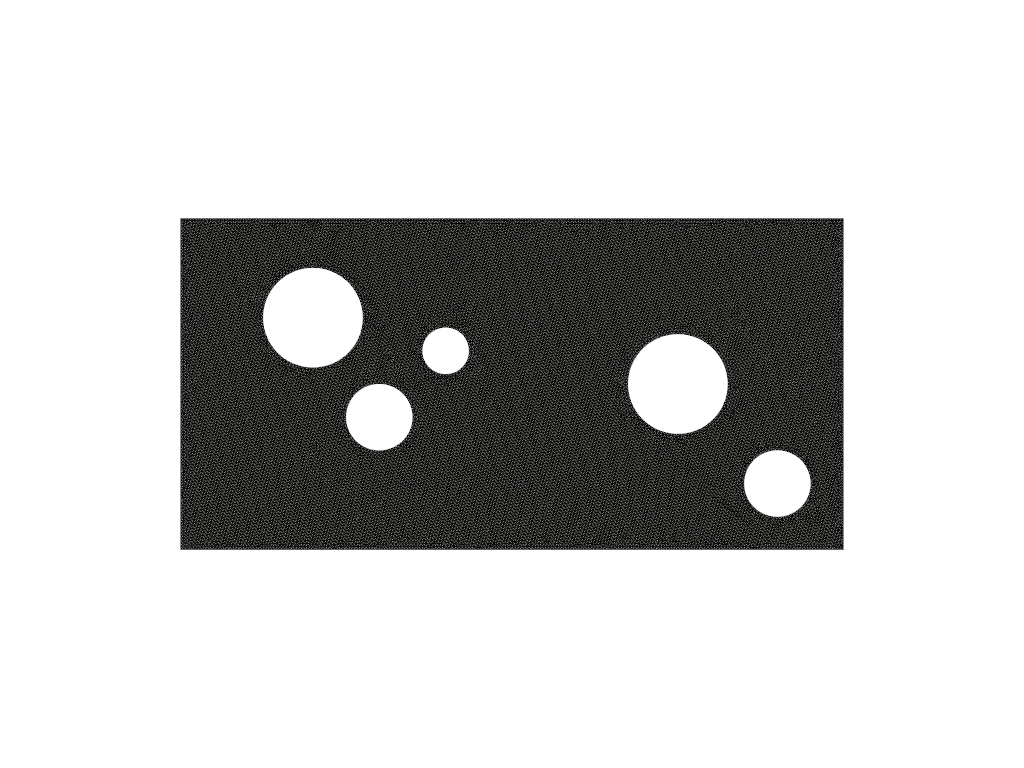

In [13]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../../meshes/rectangle_circular_holes/mesh.msh").resolve()

domain, cell_tags, facet_tags = io.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
topology, cell_type, geom = plot.vtk_mesh(domain) 

grid = pyvista.UnstructuredGrid(topology, cell_type, geom)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, color='lightgray', show_edges=True, edge_color='black', line_width=0.1)
plotter.view_xy()
plotter.show()

In [14]:
# Future task: into a helper function
gmsh.initialize()
gmsh.option.setNumber("General.Terminal", 1)
gmsh.open(str(meshfile))

phy_groups = gmsh.model.getPhysicalGroups()
name_to_id = {
    gmsh.model.getPhysicalName(dim, tag): tag for dim, tag in phy_groups
}
print(name_to_id)

gmsh.finalize()

Info    : Reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'...
Info    : 53 entities
Info    : 21555 nodes
Info    : 43118 elements
{'Inflow': 2, 'Outflow': 3, 'Walls': 4, 'Obstacle1': 5, 'Obstacle2': 6, 'Obstacle3': 7, 'Obstacle4': 8, 'Obstacle5': 9, 'Volume': 1}
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/rectangle_circular_holes/mesh.msh'


In [15]:
# Function spaces for v and p
V = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 2, shape=(2,)))
Q = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1))

# Temporal parameters
t = 0.0
T = 10.0
num_steps = 200
dt = T / num_steps
time_steps = np.arange(t, T, dt)

# Trial and test functions
u = TrialFunction(V)
v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

# Functions
u_n = Function(V)
u_tent = Function(V)
u_new = Function(V)
p_n = Function(Q)
p_new = Function(Q)
f = Constant(domain, PETSc.ScalarType((0.0, 0.0)))

# Define strain-rate tensor
def epsilon(u):
    return sym(nabla_grad(u))

# Define stress tensor
def sigma(u, p):
    return 2 * mu * epsilon(u) - p * Identity(len(u))

u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(domain)
f = Constant(domain, PETSc.ScalarType((0, 0)))
k = Constant(domain, PETSc.ScalarType(dt))
mu = Constant(domain, PETSc.ScalarType(1.5e-4))
rho = Constant(domain, PETSc.ScalarType(1.2))

In [16]:
# Define the variational problem for the first step
p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(mu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))

# Define variational problem for step 2
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_new) * q * dx)

# Define variational problem for step 3
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_new, v) * dx - k * dot(nabla_grad(p_new - p_n), v) * dx)


In [17]:
# No slip conditions
zero = Function(V)
zero.x.array[:] = 0.0

walls_tag      = name_to_id["Walls"]
obstacle1_tag  = name_to_id["Obstacle1"]
obstacle2_tag  = name_to_id["Obstacle2"]
obstacle3_tag  = name_to_id["Obstacle3"]
obstacle4_tag  = name_to_id["Obstacle4"]
obstacle5_tag  = name_to_id["Obstacle5"]

fdim = domain.topology.dim - 1

walls_dofs = fem.locate_dofs_topological(V, fdim, facet_tags.find(walls_tag))
obs1_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle1_tag))
obs2_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle2_tag))
obs3_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle3_tag))
obs4_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle4_tag))
obs5_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle5_tag))

bc_walls = fem.dirichletbc(zero, walls_dofs)
bc_obs1  = fem.dirichletbc(zero, obs1_dofs)
bc_obs2  = fem.dirichletbc(zero, obs2_dofs)
bc_obs3  = fem.dirichletbc(zero, obs3_dofs)
bc_obs4  = fem.dirichletbc(zero, obs4_dofs)
bc_obs5  = fem.dirichletbc(zero, obs5_dofs)

bcs = [bc_walls, bc_obs1, bc_obs2, bc_obs3, bc_obs4, bc_obs5]



In [18]:
# Inflow boundary
inflow_tag = name_to_id["Inflow"]

fdim = domain.topology.dim - 1
inflow_facets = facet_tags.find(inflow_tag)
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)

inflow_profile = Function(V)

x = V.tabulate_dof_coordinates().T
inflow_dofs_coords = x[:, inflow_dofs]

y_centered = (inflow_dofs_coords[1] - y_lim / 2.0) / (y_lim / 2.0)
u_val = 4.0 * (1 - y_centered) * y_centered

inflow_profile.x.array[:] = 0.0
inflow_profile.x.array[inflow_dofs * 2] = u_val

bc_in = fem.dirichletbc(inflow_profile, inflow_dofs)

p_out = Function(Q)
p_out.x.array[:] = 0.0

outflow_tag = name_to_id["Outflow"]
outflow_dofs = fem.locate_dofs_topological(Q, fdim, facet_tags.find(outflow_tag))

bc_out = fem.dirichletbc(p_out, outflow_dofs)

In [19]:
# bcs summary
velocity_bcs = [bc_in, bc_walls, bc_obs1, bc_obs2, bc_obs3, bc_obs4, bc_obs5]
pressure_bcs = [bc_out]

Converged after 4 iterations.
Final L2 err = 6.27e-09


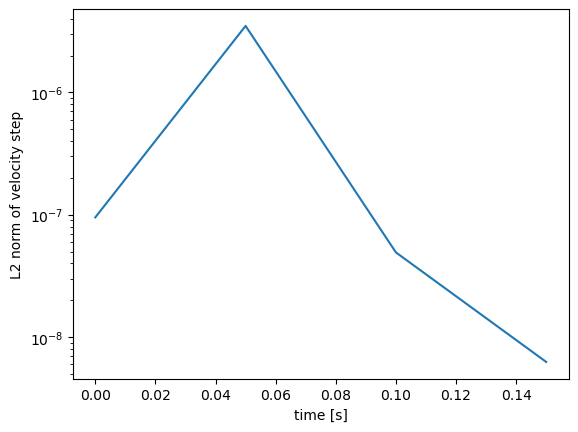

In [20]:
# Set up and solve

tentative_velocity_problem = LinearProblem(a1, L1, velocity_bcs, u_tent, 
                                           petsc_options={"ksp_type": "gmres"})
pressure_problem = LinearProblem(a2, L2, pressure_bcs, p_new)
velocity_correction_problem = LinearProblem(a3, L3, velocity_bcs, u_new)

# Error form
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V) 
l2_norm_squared = form(inner(u_diff, u_diff) * dx)
l2_errors = np.zeros(num_steps)
it_conv = np.inf

for idx, t_i in enumerate(time_steps):
    t = t_i
    tentative_velocity_problem.solve()
    pressure_problem.solve()
    velocity_correction_problem.solve()
    u_diff.x.array[:] = u_new.x.array - u_n.x.array
    l2_errors[idx] = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    
    if t_i > time_steps[0]:
        if abs(l2_errors[idx] - l2_errors[idx - 1]) < 1e-7:
            it_conv = idx
            print(f"Converged after {idx + 1} iterations.")
            print(f"Final L2 err = {l2_errors[it_conv]:.2e}")
            
            break
    u_n.x.array[:] = u_new.x.array
    p_n.x.array[:] = p_new.x.array
    sys.stdout.flush()


if it_conv == np.inf:
    print(f"Reached max number of iterations ({num_steps}). L2 Error: {l2_errors[-1]:.2e}")

if it_conv == np.inf:
    plt.semilogy(time_steps, l2_errors)
else:
    plt.semilogy(time_steps[0:it_conv+1], l2_errors[0:it_conv+1])
plt.xlabel("time [s]")
plt.ylabel("L2 norm of velocity step")
sys.stdout.flush()


In [ ]:
output_dir =  Path("./output_results").resolve()

dom_cell = domain.basix_cell()
V_u_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))
V_p_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1))

u_vis = Function(V_u_vis)
p_vis = Function(V_p_vis)

u_vis.interpolate(u_new)
p_vis.interpolate(p_new)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "velocity.xdmf", "w") as f_u:
    f_u.write_mesh(domain)
    u_vis.name = "velocity"
    f_u.write_function(u_vis, 0)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "pressure.xdmf", "w") as f_p:
    f_p.write_mesh(domain)
    p_vis.name = "pressure"
    f_p.write_function(p_vis, 0)


# Write solution also to .bp file
bp_filename = Path(output_dir / "velocity.bp")
adios4dolfinx.write_mesh(bp_filename, domain, )
adios4dolfinx.write_meshtags(bp_filename, domain, facet_tags, meshtag_name="facet_tags")
adios4dolfinx.write_function(bp_filename, u_vis, name="velocity")

AttributeError: module 'adios2' has no attribute 'ADIOS'

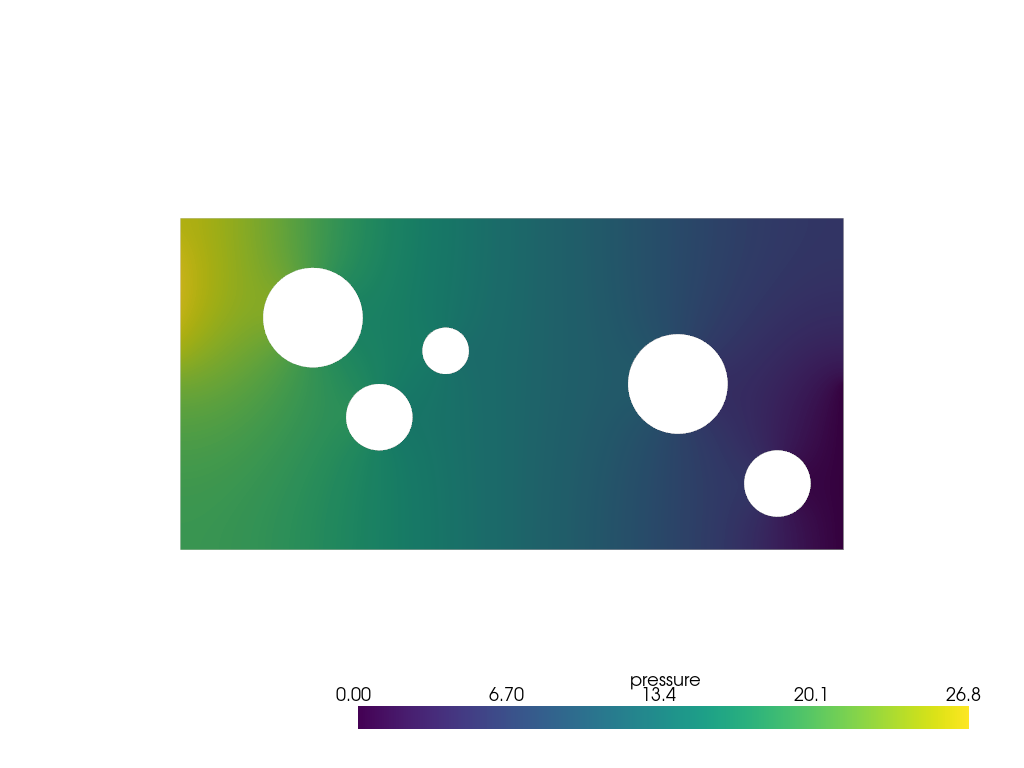

In [ ]:
pressure_array = p_vis.x.array
grid.point_data["pressure"] = pressure_array

plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="pressure", cmap="viridis", show_edges=False)
plotter.view_xy()
plotter.show()

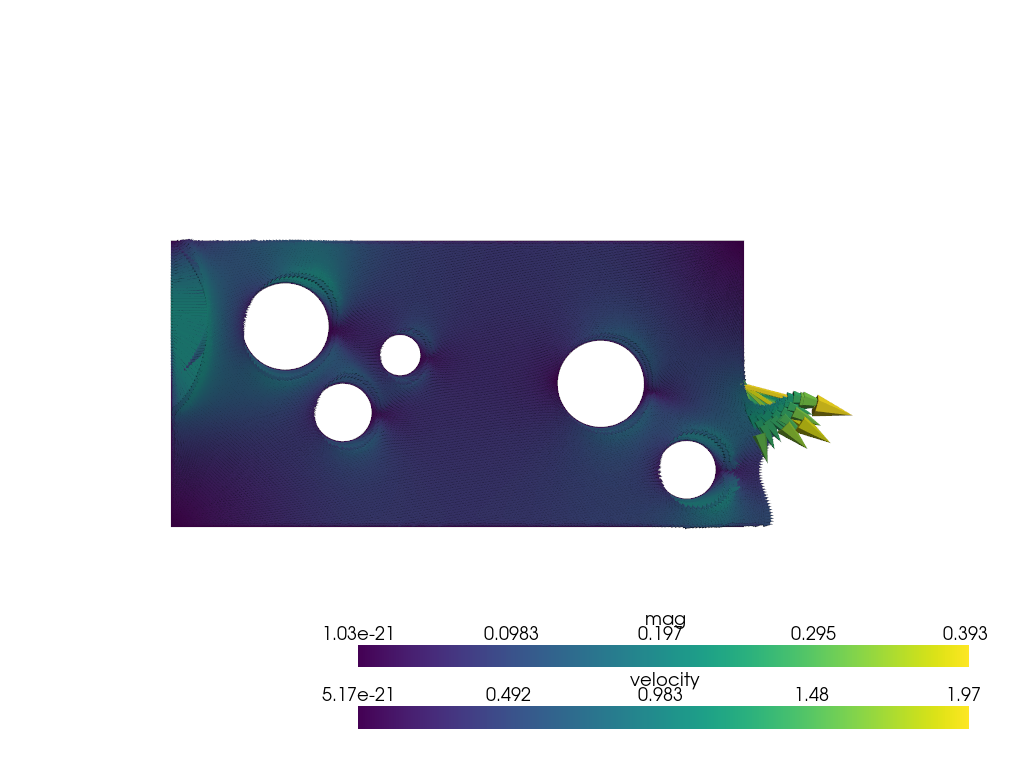

In [ ]:
velocity_array = u_vis.x.array.reshape((-1, domain.geometry.dim))
velocity_array = np.hstack((velocity_array, np.zeros((np.size(velocity_array, 0), 1))))
grid.point_data["velocity"] = velocity_array

plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="velocity", cmap="viridis", show_edges=False)
plotter.add_arrows(grid.points, velocity_array, mag=0.2)
plotter.camera.zoom(1.2)
plotter.view_xy()
plotter.show()
